# Fracture — Pipeline Conformance Deep Dive

This notebook shows **why** a pipeline receives the conformance score it does.

We cover four pipelines:
- **payment_settlements_daily** — healthy baseline
- **trade_positions_sftp** — bilateral gap (the core finding)
- **customer_risk_features** — silent failures
- **grid_corehours_calc** — slow drift

For each pipeline we show:
1. The raw event data (what the parquet actually contains)
2. The contract specification
3. The Petri net (normative process model)
4. The token replay result (where fitness comes from)
5. The conformance score breakdown
6. The bilateral gap (for pipelines with consumer events)

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from datetime import date, timedelta, datetime
from pathlib import Path

# Fracture modules
from fracture.schema import load_contract
from fracture.conformance import compute_conformance
from fracture.petri import contract_to_petri_net, net_summary
from fracture.converter import dataframe_to_eventlog
from fracture.ingest import validate_format

import pm4py
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

plt.style.use('dark_background')
TEAL   = '#1D9E75'
AMBER  = '#D4A857'
RED    = '#D85A30'
BLUE   = '#6BA3D6'
PURPLE = '#A89EF0'
GREY   = '#5E5C58'

TODAY = date.today().strftime('%Y%m%d')
print(f'Setup complete. Date: {TODAY}')

Setup complete. Date: 20260503


---
## Helper functions

In [2]:
def load_events(pipeline_id):
    """Load producer and consumer event files for a pipeline."""
    base = Path(f'../inputs/{pipeline_id}')
    
    prod_files = sorted(base.glob('producer_*.parquet'))
    cons_files = sorted(base.glob('consumer_*.parquet'))
    
    prod = pd.concat([pd.read_parquet(f) for f in prod_files], ignore_index=True) if prod_files else pd.DataFrame()
    cons = pd.concat([pd.read_parquet(f) for f in cons_files], ignore_index=True) if cons_files else None
    
    prod['timestamp'] = pd.to_datetime(prod['timestamp'], utc=True)
    if cons is not None and len(cons) > 0:
        cons['timestamp'] = pd.to_datetime(cons['timestamp'], utc=True)
    else:
        cons = None
    
    return prod, cons


def load_contract_for(pipeline_id):
    """Load the contract YAML for a pipeline."""
    return load_contract(f'../contracts/{pipeline_id}.yaml')


def show_events_table(prod, cons=None, n=8):
    """Show first N rows of event data — makes parquet readable."""
    print(f'Producer events: {len(prod)} rows, {prod.pipeline_run_id.nunique()} runs')
    display(prod.sort_values('timestamp').head(n).style
            .set_properties(**{'font-size': '11px'})
            .format({'timestamp': lambda x: str(x)[:19]}))
    
    if cons is not None:
        print(f'\nConsumer events: {len(cons)} rows, {cons.pipeline_run_id.nunique()} runs')
        display(cons.sort_values('timestamp').head(n).style
                .set_properties(**{'font-size': '11px'})
                .format({'timestamp': lambda x: str(x)[:19]}))


def show_contract_summary(contract):
    """Print contract specification cleanly."""
    print(f'  pipeline_id    : {contract.pipeline_id}')
    print(f'  producer_team  : {contract.producer_team}')
    print(f'  consumer_team  : {contract.consumer_team}')
    print(f'  window         : {contract.expected_start} → {contract.expected_end} ({contract.window_minutes()} min)')
    print(f'  p50/p95/p99    : {contract.p50_minutes}m / {contract.p95_minutes}m / {contract.p99_minutes}m')
    print(f'  grace          : {contract.grace_minutes} min')
    print(f'  deadline       : {contract.effective_deadline_minutes()} min')
    print(f'  criticality    : {contract.criticality}')
    print(f'  status         : {contract.status}')
    s = net_summary(contract)
    print(f'  petri net      : {s["n_places"]}p {s["n_transitions"]}t {s["n_arcs"]}a')
    print(f'  soundness      : {s["soundness_basis"][:60]}')


def plot_conformance_breakdown(result, title):
    """Bar chart showing seq/timing/completeness contributions."""
    d = result.diagnostics
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, color='white', y=1.02)
    
    # Left: component contributions
    ax = axes[0]
    components  = ['Sequence\n×0.35', 'Timing\n×0.50', 'Completeness\n×0.15']
    raw_scores  = [d.sequence_fitness, d.timing_score, d.completeness_score]
    weighted    = [d.sequence_fitness*0.35, d.timing_score*0.50, d.completeness_score*0.15]
    colors      = [PURPLE, TEAL, BLUE]
    
    bars = ax.bar(components, weighted, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.axhline(y=result.final_score, color=AMBER, linestyle='--', linewidth=1.5,
               label=f'Final score: {result.final_score:.3f}')
    
    for bar, raw, w in zip(bars, raw_scores, weighted):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{raw:.3f}', ha='center', va='bottom', fontsize=9, color='white')
    
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Weighted contribution')
    ax.set_title('Formula breakdown')
    ax.legend(fontsize=9)
    ax.set_facecolor('#1C1C1C')
    
    # Right: score gauge
    ax2 = axes[1]
    zone_colors = {'GREEN': TEAL, 'AMBER': AMBER, 'RED': RED, 'BREACH': '#8B0000'}
    zone_color  = zone_colors.get(result.timing_zone, GREY)
    
    theta = np.linspace(0, np.pi, 100)
    ax2.plot(np.cos(theta), np.sin(theta), color=GREY, linewidth=8, alpha=0.3)
    
    score_capped = min(1.05, result.final_score)
    score_angle  = np.pi * (1 - score_capped / 1.05)
    ax2.plot(np.cos(np.linspace(score_angle, np.pi, 50)),
             np.sin(np.linspace(score_angle, np.pi, 50)),
             color=zone_color, linewidth=8, alpha=0.9)
    
    ax2.text(0, 0.3, f'{result.final_score:.1%}', ha='center', va='center',
             fontsize=22, fontweight='bold', color=zone_color)
    ax2.text(0, 0.0, result.timing_zone, ha='center', va='center',
             fontsize=12, color=zone_color, alpha=0.8)
    ax2.text(0, -0.25, f'conf={result.confidence_level}  pattern={result.pattern}',
             ha='center', va='center', fontsize=9, color=GREY)
    
    ax2.set_xlim(-1.3, 1.3)
    ax2.set_ylim(-0.4, 1.3)
    ax2.set_aspect('equal')
    ax2.axis('off')
    ax2.set_title('Conformance score')
    ax2.set_facecolor('#1C1C1C')
    
    fig.patch.set_facecolor('#0E0E0E')
    plt.tight_layout()
    plt.show()


def plot_token_replay(log, net, im, fm, contract, title):
    """Show token replay results per trace."""
    results = token_replay.apply(log, net, im, fm)
    
    fitnesses = [r['trace_fitness'] for r in results]
    missing   = [r.get('missing_tokens', 0) for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{title} — Token Replay', fontsize=12, color='white')
    
    # Fitness per trace
    ax = axes[0]
    colors = [TEAL if f >= 0.95 else AMBER if f >= 0.75 else RED for f in fitnesses]
    ax.bar(range(len(fitnesses)), fitnesses, color=colors, alpha=0.8, width=0.7)
    ax.axhline(y=np.mean(fitnesses), color=AMBER, linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(fitnesses):.3f}')
    ax.set_xlabel('Trace (pipeline run)')
    ax.set_ylabel('Token replay fitness')
    ax.set_title('Fitness per trace')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.set_facecolor('#1C1C1C')
    
    green_p  = mpatches.Patch(color=TEAL,  label='≥0.95 (healthy)')
    amber_p  = mpatches.Patch(color=AMBER, label='0.75-0.95 (warning)')
    red_p    = mpatches.Patch(color=RED,   label='<0.75 (violation)')
    ax.legend(handles=[green_p, amber_p, red_p], fontsize=8, loc='lower right')
    
    # Missing tokens distribution
    ax2 = axes[1]
    unique_missing = sorted(set(missing))
    counts = [missing.count(m) for m in unique_missing]
    bar_colors = [TEAL if m == 0 else AMBER if m == 1 else RED for m in unique_missing]
    ax2.bar([str(m) for m in unique_missing], counts,
            color=bar_colors, alpha=0.8, width=0.5)
    ax2.set_xlabel('Missing tokens per trace')
    ax2.set_ylabel('Number of traces')
    ax2.set_title('Missing token distribution')
    ax2.set_facecolor('#1C1C1C')
    
    ax2.text(0.98, 0.95,
             f'0 missing = activity fired correctly\n'
             f'1+ missing = activity skipped or out of order',
             transform=ax2.transAxes, ha='right', va='top',
             fontsize=8, color=GREY,
             bbox=dict(boxstyle='round', facecolor='#1C1C1C', alpha=0.8))
    
    fig.patch.set_facecolor('#0E0E0E')
    plt.tight_layout()
    plt.show()
    
    return results


def plot_bilateral_gap(prod, cons, pipeline_id):
    """Show producer vs consumer DATA_AVAILABLE timestamps per run."""
    if cons is None:
        print('No consumer events — bilateral comparison not available')
        return
    
    prod_da = (prod[prod.activity == 'DATA_AVAILABLE']
               .groupby('pipeline_run_id')['timestamp'].first())
    cons_da = (cons[cons.activity == 'DATA_AVAILABLE']
               .groupby('pipeline_run_id')['timestamp'].first())
    
    common = prod_da.index.intersection(cons_da.index)
    if len(common) == 0:
        print('No matching run IDs between producer and consumer')
        return
    
    gaps = [(cons_da[r] - prod_da[r]).total_seconds()/60 for r in common]
    runs = list(range(len(common)))
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{pipeline_id} — Bilateral Gap Analysis', fontsize=12, color='white')
    
    # Gap per run
    ax = axes[0]
    gap_colors = [TEAL if g <= 5 else AMBER if g <= 20 else RED for g in gaps]
    ax.bar(runs, gaps, color=gap_colors, alpha=0.8, width=0.7)
    ax.axhline(y=np.mean(gaps), color=AMBER, linestyle='--', linewidth=1.5,
               label=f'Mean: {np.mean(gaps):.1f} min')
    ax.axhline(y=np.percentile(gaps, 95), color=RED, linestyle=':', linewidth=1.5,
               label=f'p95: {np.percentile(gaps, 95):.1f} min')
    ax.set_xlabel('Pipeline run')
    ax.set_ylabel('Gap (minutes)')
    ax.set_title('Consumer DATA_AVAILABLE delay vs Producer')
    ax.legend(fontsize=9)
    ax.set_facecolor('#1C1C1C')
    
    ax.text(0.02, 0.97,
            'Gap = time consumer experiences data\nminus time producer thinks data is ready',
            transform=ax.transAxes, va='top', fontsize=8, color=GREY,
            bbox=dict(boxstyle='round', facecolor='#1C1C1C', alpha=0.8))
    
    # Gap trend over time
    ax2 = axes[1]
    ax2.scatter(runs, gaps, color=TEAL, alpha=0.6, s=25, zorder=3)
    
    if len(gaps) >= 3:
        z    = np.polyfit(runs, gaps, 1)
        p    = np.poly1d(z)
        trend_color = RED if z[0] > 0 else TEAL
        ax2.plot(runs, p(runs), color=trend_color, linewidth=2,
                 label=f'Trend: {z[0]:+.2f} min/run ({"widening" if z[0]>0 else "narrowing"})')
    
    ax2.set_xlabel('Pipeline run')
    ax2.set_ylabel('Gap (minutes)')
    ax2.set_title('Gap trend over time')
    ax2.legend(fontsize=9)
    ax2.set_facecolor('#1C1C1C')
    
    # Annotation
    mean_gap = np.mean(gaps)
    print(f'  Mean gap    : {mean_gap:.1f} min')
    print(f'  p95 gap     : {np.percentile(gaps, 95):.1f} min')
    print(f'  Max gap     : {max(gaps):.1f} min')
    if len(gaps) >= 3:
        trend = np.polyfit(runs, gaps, 1)[0]
        print(f'  Trend       : {trend:+.2f} min/run ({"WIDENING" if trend > 0 else "narrowing"})')
    
    fig.patch.set_facecolor('#0E0E0E')
    plt.tight_layout()
    plt.show()


def plot_completeness(prod, contract, title):
    """Show which runs completed and which were silent."""
    terminal = contract.log_contract.terminal_event
    
    scheduled = set(prod[prod.activity=='SCHEDULED']['pipeline_run_id'])
    completed = set(prod[prod.activity==terminal]['pipeline_run_id'])
    silent    = scheduled - completed
    
    # Get dates
    run_dates = {}
    for _, row in prod[prod.activity=='SCHEDULED'].iterrows():
        run_dates[row.pipeline_run_id] = row.timestamp.date()
    
    # Build timeline
    all_runs  = sorted(scheduled, key=lambda r: run_dates.get(r, date.min))
    statuses  = ['completed' if r in completed else 'silent' for r in all_runs]
    days      = [run_dates.get(r, date.min) for r in all_runs]
    weekdays  = [d.strftime('%a') for d in days]
    
    fig, ax = plt.subplots(figsize=(14, 3))
    fig.suptitle(f'{title} — Completeness Timeline', fontsize=12, color='white')
    
    for i, (status, wd) in enumerate(zip(statuses, weekdays)):
        color = TEAL if status == 'completed' else RED
        ax.bar(i, 1, color=color, alpha=0.8, width=0.8)
        if status == 'silent':
            ax.text(i, 0.5, wd, ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    
    ax.set_xlim(-0.5, len(all_runs)-0.5)
    ax.set_ylim(0, 1.3)
    ax.set_xlabel('Pipeline runs (chronological)')
    ax.set_yticks([])
    ax.set_facecolor('#1C1C1C')
    
    comp_p   = mpatches.Patch(color=TEAL, label=f'Completed ({len(completed)})')
    silent_p = mpatches.Patch(color=RED,  label=f'Silent — no {terminal} ({len(silent)})')
    ax.legend(handles=[comp_p, silent_p], fontsize=9)
    
    ax.text(0.02, 1.25,
            f'Completeness = {len(completed)}/{len(scheduled)} = {len(completed)/max(len(scheduled),1):.0%}   '
            f'Silent weekdays visible as RED bars with day labels',
            transform=ax.transAxes, fontsize=9, color=GREY)
    
    fig.patch.set_facecolor('#0E0E0E')
    plt.tight_layout()
    plt.show()
    
    print(f'  Scheduled   : {len(scheduled)}')
    print(f'  Completed   : {len(completed)}')
    print(f'  Silent      : {len(silent)}')
    print(f'  Completeness: {len(completed)/max(len(scheduled),1):.1%}')
    if silent:
        silent_days = sorted(set(run_dates.get(r,'?').strftime('%A') for r in silent))
        print(f'  Silent days : {silent_days}')


print('All helper functions loaded.')

All helper functions loaded.


---
## Pipeline 1 — payment_settlements_daily
### The healthy baseline. What a conformant pipeline looks like.

In [4]:
PID = 'payment_settlements_daily'

prod, cons   = load_events(PID)
contract     = load_contract_for(PID)
net, im, fm  = contract_to_petri_net(contract)

print('=== CONTRACT ===')
show_contract_summary(contract)
print()
print('=== RAW EVENT DATA (first 8 rows) ===')
show_events_table(prod, cons, n=8)

=== CONTRACT ===
  pipeline_id    : payment_settlements_daily
  producer_team  : payments-platform
  consumer_team  : settlement-ops
  window         : 06:00 → 08:30 (150 min)
  p50/p95/p99    : 41m / 43m / 44m
  grace          : 30 min
  deadline       : 74 min
  criticality    : Criticality.HIGH
  status         : ContractStatus.ACTIVE
  petri net      : 6p 5t 10a
  soundness      : trivially guaranteed — strictly linear WF-net: 1-bounded, si

=== RAW EVENT DATA (first 8 rows) ===
Producer events: 120 rows, 30 runs


,pipeline_run_id,activity,timestamp,team,pipeline_id
0,payment_settlements_daily_20260403,SCHEDULED,2026-04-03 05:58:00,producer,payment_settlements_daily
1,payment_settlements_daily_20260403,STARTED,2026-04-03 06:01:00,producer,payment_settlements_daily
2,payment_settlements_daily_20260403,COMPLETED,2026-04-03 06:41:35,producer,payment_settlements_daily
3,payment_settlements_daily_20260403,DATA_AVAILABLE,2026-04-03 06:41:35,producer,payment_settlements_daily
4,payment_settlements_daily_20260404,SCHEDULED,2026-04-04 05:58:00,producer,payment_settlements_daily
5,payment_settlements_daily_20260404,STARTED,2026-04-04 06:01:00,producer,payment_settlements_daily
6,payment_settlements_daily_20260404,COMPLETED,2026-04-04 06:42:30,producer,payment_settlements_daily
7,payment_settlements_daily_20260404,DATA_AVAILABLE,2026-04-04 06:42:30,producer,payment_settlements_daily



Consumer events: 120 rows, 30 runs


,pipeline_run_id,activity,timestamp,team,pipeline_id
0,payment_settlements_daily_20260403,SCHEDULED,2026-04-03 05:58:00,consumer,payment_settlements_daily
1,payment_settlements_daily_20260403,STARTED,2026-04-03 06:01:00,consumer,payment_settlements_daily
2,payment_settlements_daily_20260403,COMPLETED,2026-04-03 06:41:35,consumer,payment_settlements_daily
3,payment_settlements_daily_20260403,DATA_AVAILABLE,2026-04-03 06:47:00,consumer,payment_settlements_daily
4,payment_settlements_daily_20260404,SCHEDULED,2026-04-04 05:58:00,consumer,payment_settlements_daily
5,payment_settlements_daily_20260404,STARTED,2026-04-04 06:01:00,consumer,payment_settlements_daily
6,payment_settlements_daily_20260404,COMPLETED,2026-04-04 06:42:30,consumer,payment_settlements_daily
7,payment_settlements_daily_20260404,DATA_AVAILABLE,2026-04-04 06:47:52,consumer,payment_settlements_daily


In [5]:
# What the 4 columns actually mean
print('Activity distribution in producer log:')
print(prod.groupby('activity').size().to_string())
print()
print('Unique pipeline runs (one per day):')
print(f'  {prod.pipeline_run_id.nunique()} runs over {(prod.timestamp.max()-prod.timestamp.min()).days} days')
print()
print('Execution duration per run (STARTED → COMPLETED):')
durations = []
for run_id, group in prod.groupby('pipeline_run_id'):
    s = group[group.activity=='STARTED']['timestamp']
    c = group[group.activity=='COMPLETED']['timestamp']
    if len(s) > 0 and len(c) > 0:
        dur = (c.iloc[0] - s.iloc[0]).total_seconds()/60
        durations.append(dur)

print(f'  p50 = {pd.Series(durations).quantile(0.50):.1f} min')
print(f'  p95 = {pd.Series(durations).quantile(0.95):.1f} min')
print(f'  p99 = {pd.Series(durations).quantile(0.99):.1f} min')
print(f'  These match what bootstrap computed: p50={contract.p50_minutes}m p99={contract.p99_minutes}m')

Activity distribution in producer log:
activity
COMPLETED         30
DATA_AVAILABLE    30
SCHEDULED         30
STARTED           30

Unique pipeline runs (one per day):
  30 runs over 29 days

Execution duration per run (STARTED → COMPLETED):
  p50 = 41.1 min
  p95 = 43.6 min
  p99 = 43.7 min
  These match what bootstrap computed: p50=41m p99=44m


Human summary: Conformant at 100%. GREEN zone. No action required.
Alert owner  : pipeline-owner

Score breakdown:
  sequence_fitness  = 1.0000  (PM4PY token replay)
  timing_score      = 1.0032  (zone model)
  completeness_score= 1.0000  (complete/total runs)
  final_score       = 1.0016  (weighted combination)
  bilateral_gap     = 5.1 min


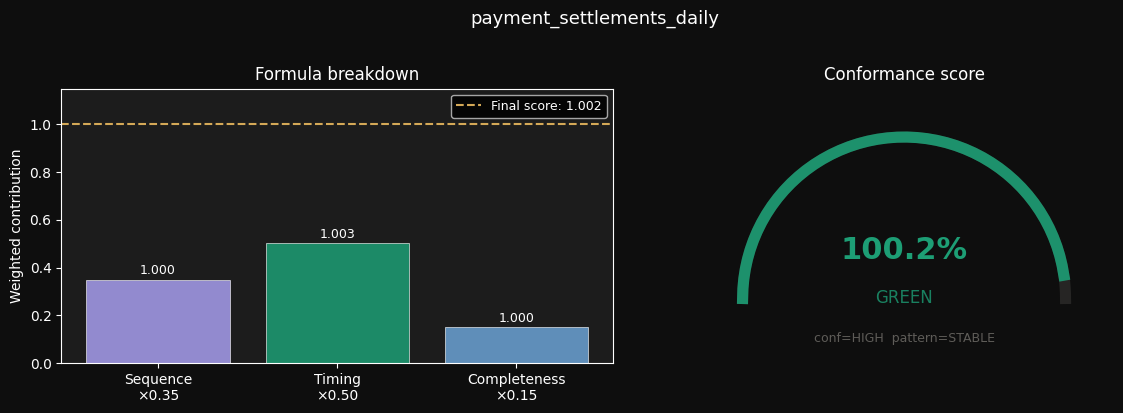

In [6]:
# Run conformance and show breakdown
result = compute_conformance(prod, contract, consumer_events=cons)

print(f'Human summary: {result.human_summary()}')
print(f'Alert owner  : {result.alert_owner()}')
print()
print(f'Score breakdown:')
print(f'  sequence_fitness  = {result.diagnostics.sequence_fitness:.4f}  (PM4PY token replay)')
print(f'  timing_score      = {result.diagnostics.timing_score:.4f}  (zone model)')
print(f'  completeness_score= {result.diagnostics.completeness_score:.4f}  (complete/total runs)')
print(f'  final_score       = {result.final_score:.4f}  (weighted combination)')
print(f'  bilateral_gap     = {result.bilateral_gap_minutes:.1f} min')

plot_conformance_breakdown(result, PID)

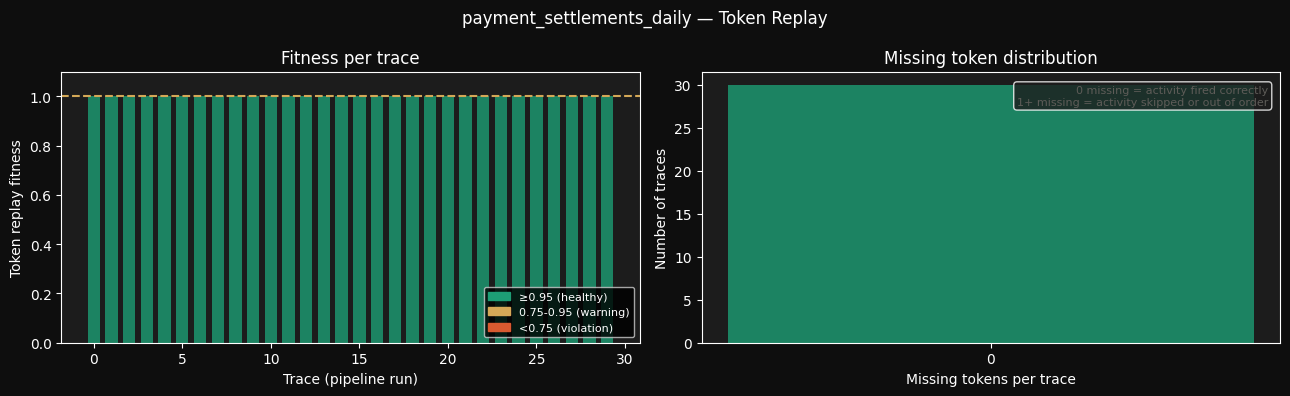


Trace 0 detail:
  fitness          : 1.0000
  missing_tokens   : 0
  remaining_tokens : 0
  reached end      : ['payment_settlements_daily_end:1']

Interpretation:
  0 missing tokens = all required activities fired in correct order
  fitness = 1.0    = perfect sequence conformance


In [7]:
# Token replay — see the Petri net at work
log = dataframe_to_eventlog(prod, contract, 'producer')
replay_results = plot_token_replay(log, net, im, fm, contract, PID)

# Show one trace in detail
r0 = replay_results[0]
print(f'\nTrace 0 detail:')
print(f'  fitness          : {r0["trace_fitness"]:.4f}')
print(f'  missing_tokens   : {r0.get("missing_tokens", 0)}')
print(f'  remaining_tokens : {r0.get("remaining_tokens", 0)}')
print(f'  reached end      : {r0.get("reached_marking", False)}')
print()
print('Interpretation:')
print('  0 missing tokens = all required activities fired in correct order')
print('  fitness = 1.0    = perfect sequence conformance')

---
## Pipeline 2 — trade_positions_sftp
### The bilateral gap. The core Fracture finding.

Both teams execute correctly. Neither is failing.
But the producer thinks data is available 25+ minutes before the consumer experiences it.
This gap is invisible to any monitoring tool that only monitors one side.

In [8]:
PID = 'trade_positions_sftp'

prod2, cons2  = load_events(PID)
contract2     = load_contract_for(PID)

print('=== CONTRACT ===')
show_contract_summary(contract2)
print()
print('=== RAW DATA (first 6 rows each side) ===')
show_events_table(prod2, cons2, n=6)

=== CONTRACT ===
  pipeline_id    : trade_positions_sftp
  producer_team  : market-risk-quant
  consumer_team  : grid-scheduler
  window         : 06:00 → 08:30 (150 min)
  p50/p95/p99    : 41m / 43m / 44m
  grace          : 30 min
  deadline       : 74 min
  criticality    : Criticality.MEDIUM
  status         : ContractStatus.ACTIVE
  petri net      : 6p 5t 10a
  soundness      : trivially guaranteed — strictly linear WF-net: 1-bounded, si

=== RAW DATA (first 6 rows each side) ===
Producer events: 120 rows, 30 runs


,pipeline_run_id,activity,timestamp,team,pipeline_id
0,trade_positions_sftp_20260403,SCHEDULED,2026-04-03 05:58:00,producer,trade_positions_sftp
1,trade_positions_sftp_20260403,STARTED,2026-04-03 06:01:00,producer,trade_positions_sftp
2,trade_positions_sftp_20260403,COMPLETED,2026-04-03 06:43:04,producer,trade_positions_sftp
3,trade_positions_sftp_20260403,DATA_AVAILABLE,2026-04-03 06:46:04,producer,trade_positions_sftp
4,trade_positions_sftp_20260404,SCHEDULED,2026-04-04 05:58:00,producer,trade_positions_sftp
5,trade_positions_sftp_20260404,STARTED,2026-04-04 06:01:00,producer,trade_positions_sftp



Consumer events: 120 rows, 30 runs


,pipeline_run_id,activity,timestamp,team,pipeline_id
0,trade_positions_sftp_20260403,SCHEDULED,2026-04-03 05:58:00,consumer,trade_positions_sftp
1,trade_positions_sftp_20260403,STARTED,2026-04-03 06:01:00,consumer,trade_positions_sftp
2,trade_positions_sftp_20260403,COMPLETED,2026-04-03 06:43:04,consumer,trade_positions_sftp
3,trade_positions_sftp_20260403,DATA_AVAILABLE,2026-04-03 07:11:46,consumer,trade_positions_sftp
4,trade_positions_sftp_20260404,SCHEDULED,2026-04-04 05:58:00,consumer,trade_positions_sftp
5,trade_positions_sftp_20260404,STARTED,2026-04-04 06:01:00,consumer,trade_positions_sftp


In [9]:
# Show the gap directly in the raw data — no conformance needed to see it
prod_da = prod2[prod2.activity=='DATA_AVAILABLE'].groupby('pipeline_run_id')['timestamp'].first()
cons_da = cons2[cons2.activity=='DATA_AVAILABLE'].groupby('pipeline_run_id')['timestamp'].first()

common = prod_da.index.intersection(cons_da.index)[:5]
print('Raw bilateral gap in the data (first 5 runs):')
print(f'{"Run ID":<40} {"Producer DA":<22} {"Consumer DA":<22} {"Gap"}')
print('-'*90)
for r in common:
    p = prod_da[r]
    c = cons_da[r]
    gap = (c - p).total_seconds()/60
    print(f'{str(r)[:38]:<40} {str(p)[:19]:<22} {str(c)[:19]:<22} {gap:.1f} min')

print()
print('Producer thinks: data available at column producer_DA')
print('Consumer says:   data available at column consumer_DA')
print('Nobody measured the difference. Until now.')

Raw bilateral gap in the data (first 5 runs):
Run ID                                   Producer DA            Consumer DA            Gap
------------------------------------------------------------------------------------------
trade_positions_sftp_20260403            2026-04-03 06:46:04    2026-04-03 07:11:46    25.7 min
trade_positions_sftp_20260404            2026-04-04 06:49:36    2026-04-04 07:14:57    25.4 min
trade_positions_sftp_20260405            2026-04-05 06:45:23    2026-04-05 07:08:43    23.3 min
trade_positions_sftp_20260406            2026-04-06 06:47:02    2026-04-06 07:10:12    23.2 min
trade_positions_sftp_20260407            2026-04-07 06:43:15    2026-04-07 07:07:52    24.6 min

Producer thinks: data available at column producer_DA
Consumer says:   data available at column consumer_DA
Nobody measured the difference. Until now.


Human summary : Pipeline healthy but bilateral gap is 28 min. Consumer receives data later than producer thinks.
Final score   : 1.0012
Bilateral gap : 28.3 min  ← THE FINDING
Gap trend     : stable
Gap p95       : 32.1 min (worst case)


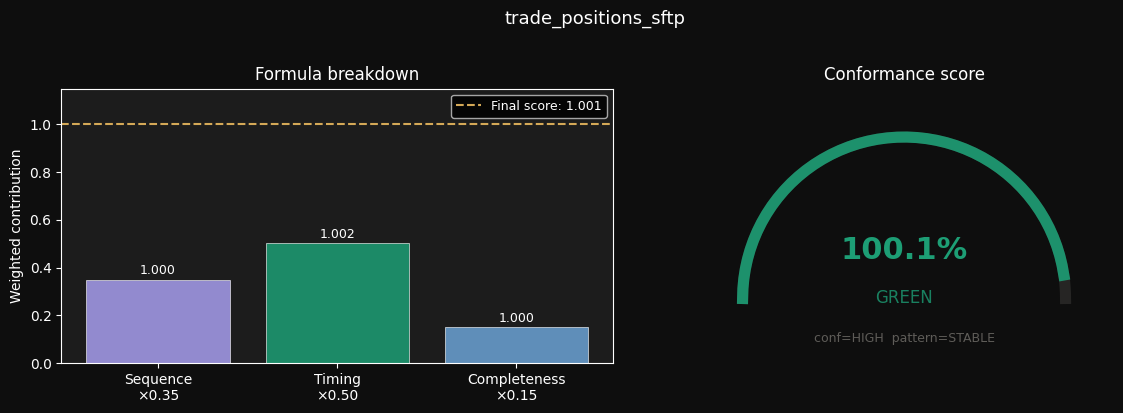

In [10]:
# Run conformance
result2 = compute_conformance(prod2, contract2, consumer_events=cons2)

print(f'Human summary : {result2.human_summary()}')
print(f'Final score   : {result2.final_score:.4f}')
print(f'Bilateral gap : {result2.bilateral_gap_minutes:.1f} min  ← THE FINDING')
print(f'Gap trend     : {result2.diagnostics.bilateral_gap_trend}')
print(f'Gap p95       : {result2.diagnostics.bilateral_gap_p95:.1f} min (worst case)')

plot_conformance_breakdown(result2, PID)

  Mean gap    : 28.3 min
  p95 gap     : 32.1 min
  Max gap     : 32.7 min
  Trend       : +0.24 min/run (WIDENING)


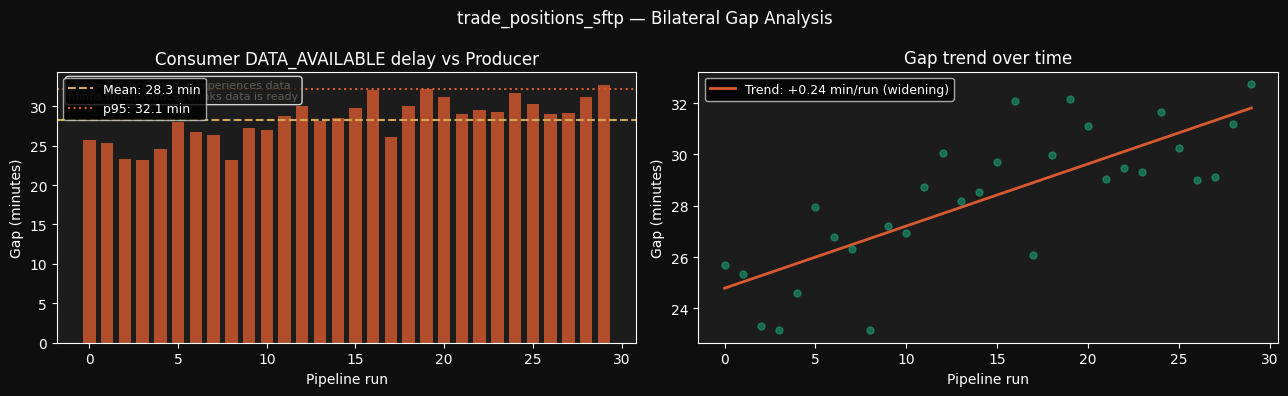

In [11]:
# Visualise the bilateral gap
plot_bilateral_gap(prod2, cons2, PID)

---
## Pipeline 3 — customer_risk_features
### Silent failures. The hardest failure mode to detect.

The pipeline does not fail. It simply does not run on Mondays and Thursdays.
No error. No alert from infrastructure monitoring.
The ML model consuming this pipeline gets stale features twice a week.
Nobody knows.

In [12]:
PID = 'customer_risk_features'

prod3, cons3  = load_events(PID)
contract3     = load_contract_for(PID)

print('=== CONTRACT ===')
show_contract_summary(contract3)
print()

# Show the silence directly in the data
print('Activity counts in producer log:')
print(prod3.groupby('activity').size().to_string())
print()
print('Key observation:')
sched = prod3[prod3.activity=='SCHEDULED']['pipeline_run_id'].nunique()
comp  = prod3[prod3.activity=='COMPLETED']['pipeline_run_id'].nunique()
print(f'  Scheduled : {sched} runs')
print(f'  Completed : {comp} runs')
print(f'  Silent    : {sched-comp} runs fired SCHEDULED but never reached COMPLETED')
print(f'  No error event. No failure event. Just absence.')

=== CONTRACT ===
  pipeline_id    : customer_risk_features
  producer_team  : aml-platform
  consumer_team  : ml-platform
  window         : 06:00 → 08:30 (150 min)
  p50/p95/p99    : 42m / 44m / 45m
  grace          : 30 min
  deadline       : 75 min
  criticality    : Criticality.HIGH
  status         : ContractStatus.ACTIVE
  petri net      : 6p 5t 10a
  soundness      : trivially guaranteed — strictly linear WF-net: 1-bounded, si

Activity counts in producer log:
activity
COMPLETED         22
DATA_AVAILABLE    22
SCHEDULED         30
STARTED           22

Key observation:
  Scheduled : 30 runs
  Completed : 22 runs
  Silent    : 8 runs fired SCHEDULED but never reached COMPLETED
  No error event. No failure event. Just absence.


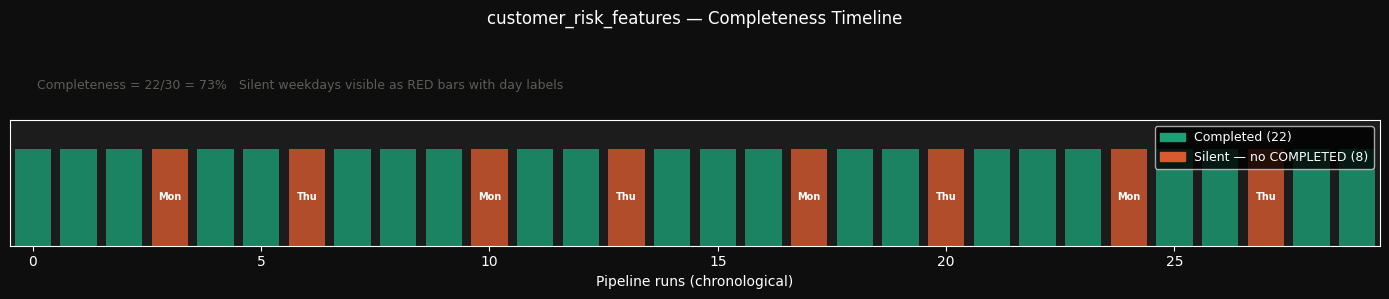

  Scheduled   : 30
  Completed   : 22
  Silent      : 8
  Completeness: 73.3%
  Silent days : ['Monday', 'Thursday']


In [13]:
# Visualise the silence
plot_completeness(prod3, contract3, PID)

replaying log with TBR, completed traces :: 100%|██████████| 2/2 [00:00<00:00, 3452.10it/s]


Human summary    : Fails on specific weekdays — infrastructure problem, not pipeline problem. Route to platform-infrastructure.
Final score      : 0.9147
Completeness     : 0.7333  ← below 0.75 threshold
Pattern          : INTERMITTENT

Why other tools miss this:
  Airflow:          shows queued+succeeded — no error
  Monte Carlo:      data looks fine on the days it runs
  Great Expectations: no data = no checks run
  Fracture:         completeness = completed/scheduled = 0.70 → AMBER


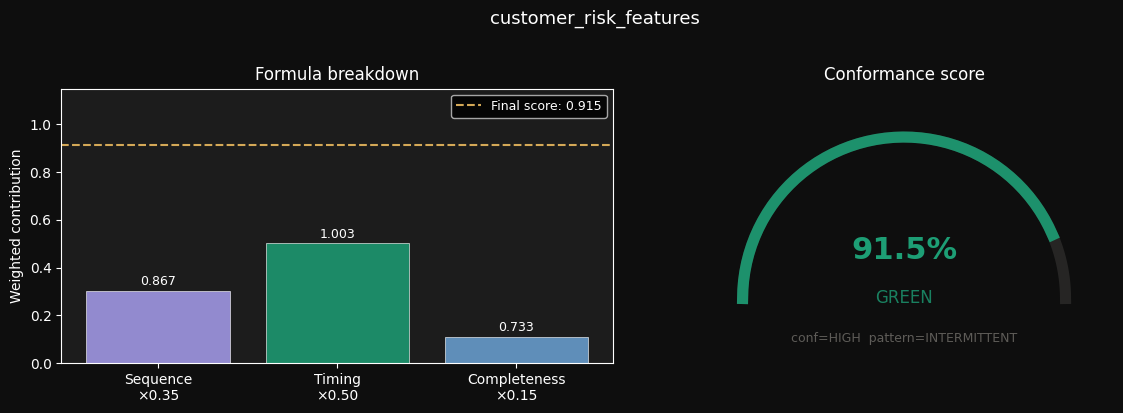

In [14]:
# Run conformance
result3 = compute_conformance(prod3, contract3, consumer_events=cons3)

print(f'Human summary    : {result3.human_summary()}')
print(f'Final score      : {result3.final_score:.4f}')
print(f'Completeness     : {result3.diagnostics.completeness_score:.4f}  ← below 0.75 threshold')
print(f'Pattern          : {result3.pattern}')

print()
print('Why other tools miss this:')
print('  Airflow:          shows queued+succeeded — no error')
print('  Monte Carlo:      data looks fine on the days it runs')
print('  Great Expectations: no data = no checks run')
print('  Fracture:         completeness = completed/scheduled = 0.70 → AMBER')

plot_conformance_breakdown(result3, PID)

---
## Pipeline 4 — grid_corehours_calc
### Slow drift. The pattern nobody catches.

A pipeline that worked fine six months ago.
Conformance declining 2 minutes per week as workload grows.
Individual days never look alarming.
By the time it breaches the SLA the team has no history of the decline.

In [15]:
PID = 'grid_corehours_calc'

prod4, cons4  = load_events(PID)
contract4     = load_contract_for(PID)

print('=== CONTRACT ===')
show_contract_summary(contract4)
print()

# Show execution times trending upward
durations4 = []
run_order4 = []
for i, (run_id, group) in enumerate(
        sorted(prod4.groupby('pipeline_run_id'),
               key=lambda x: x[1]['timestamp'].min())):
    s = group[group.activity=='STARTED']['timestamp']
    c = group[group.activity=='COMPLETED']['timestamp']
    if len(s) > 0 and len(c) > 0:
        dur = (c.iloc[0] - s.iloc[0]).total_seconds()/60
        durations4.append(dur)
        run_order4.append(i)

if len(durations4) >= 3:
    z = np.polyfit(run_order4, durations4, 1)
    print(f'Execution time trend:')
    print(f'  First run  : {durations4[0]:.1f} min')
    print(f'  Last run   : {durations4[-1]:.1f} min')
    print(f'  Slope      : {z[0]:+.2f} min/run  ({"increasing" if z[0]>0 else "decreasing"})')
    print(f'  p99 today  : {pd.Series(durations4).quantile(0.99):.1f} min')
    print(f'  Contract   : {contract4.p99_minutes} min')

=== CONTRACT ===
  pipeline_id    : grid_corehours_calc
  producer_team  : risk-technology
  consumer_team  : reporting-platform
  window         : 06:00 → 08:30 (150 min)
  p50/p95/p99    : 48m / 51m / 52m
  grace          : 30 min
  deadline       : 82 min
  criticality    : Criticality.MEDIUM
  status         : ContractStatus.ACTIVE
  petri net      : 6p 5t 10a
  soundness      : trivially guaranteed — strictly linear WF-net: 1-bounded, si

Execution time trend:
  First run  : 44.2 min
  Last run   : 50.8 min
  Slope      : +0.24 min/run  (increasing)
  p99 today  : 52.7 min
  Contract   : 52 min


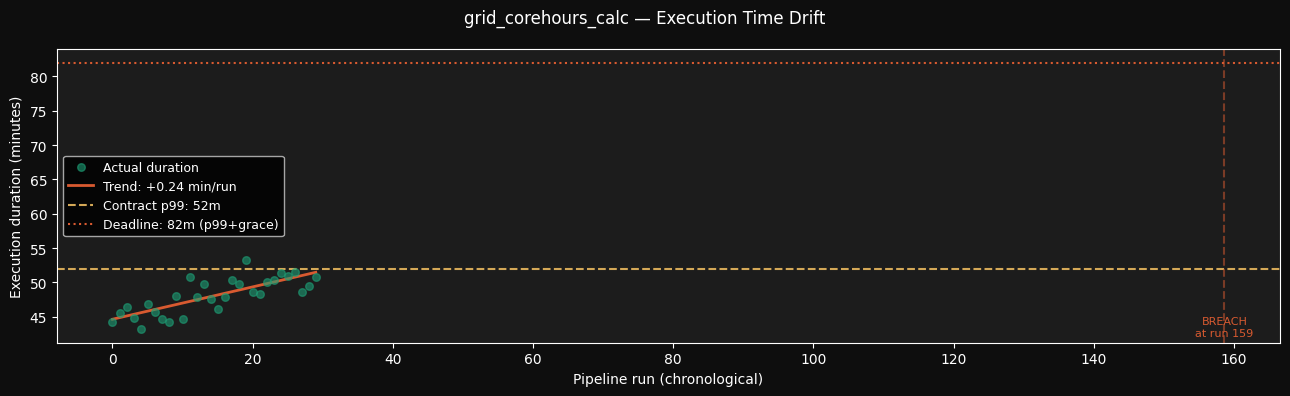

Fracture detects this because it measures TREND, not just today.
A static threshold alert would not fire until breach.
Fracture shows DRIFTING pattern with days_to_breach estimate.


In [16]:
# Plot the drift
fig, ax = plt.subplots(figsize=(13, 4))
fig.suptitle(f'{PID} — Execution Time Drift', fontsize=12, color='white')

ax.scatter(run_order4, durations4, color=TEAL, alpha=0.6, s=30, zorder=3, label='Actual duration')

if len(durations4) >= 3:
    z    = np.polyfit(run_order4, durations4, 1)
    p    = np.poly1d(z)
    ax.plot(run_order4, p(run_order4), color=RED, linewidth=2,
            label=f'Trend: {z[0]:+.2f} min/run')

ax.axhline(y=contract4.p99_minutes,     color=AMBER, linestyle='--', linewidth=1.5,
           label=f'Contract p99: {contract4.p99_minutes}m')
ax.axhline(y=contract4.effective_deadline_minutes(), color=RED,   linestyle=':',  linewidth=1.5,
           label=f'Deadline: {contract4.effective_deadline_minutes()}m (p99+grace)')

ax.set_xlabel('Pipeline run (chronological)')
ax.set_ylabel('Execution duration (minutes)')
ax.legend(fontsize=9)
ax.set_facecolor('#1C1C1C')
fig.patch.set_facecolor('#0E0E0E')

# Add annotation when it will breach
if len(durations4) >= 3:
    z = np.polyfit(run_order4, durations4, 1)
    if z[0] > 0:
        breach_run = (contract4.effective_deadline_minutes() - z[1]) / z[0]
        if breach_run > max(run_order4):
            ax.axvline(x=breach_run, color=RED, linestyle='--', alpha=0.5,
                       label=f'Predicted breach: run {breach_run:.0f}')
            ax.text(breach_run, ax.get_ylim()[0]+1, f'BREACH\nat run {breach_run:.0f}',
                    ha='center', color=RED, fontsize=8)

plt.tight_layout()
plt.show()

print('Fracture detects this because it measures TREND, not just today.')
print('A static threshold alert would not fire until breach.')
print('Fracture shows DRIFTING pattern with days_to_breach estimate.')

Human summary    : Conformant at 100%. GREEN zone. No action required.
Final score      : 1.0044
Pattern          : STABLE
Timing zone      : GREEN
Variance CV      : 0.0000  (higher = more variable)


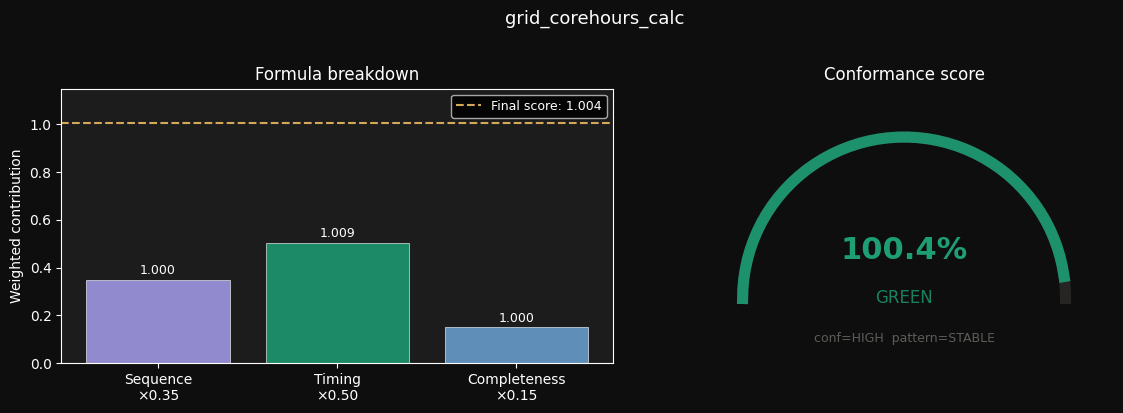

In [17]:
# Run conformance
result4 = compute_conformance(prod4, contract4, consumer_events=cons4)

print(f'Human summary    : {result4.human_summary()}')
print(f'Final score      : {result4.final_score:.4f}')
print(f'Pattern          : {result4.pattern}')
print(f'Timing zone      : {result4.timing_zone}')
print(f'Variance CV      : {result4.diagnostics.variance_cv:.4f}  (higher = more variable)')

plot_conformance_breakdown(result4, PID)

---
## Summary — all four pipelines compared

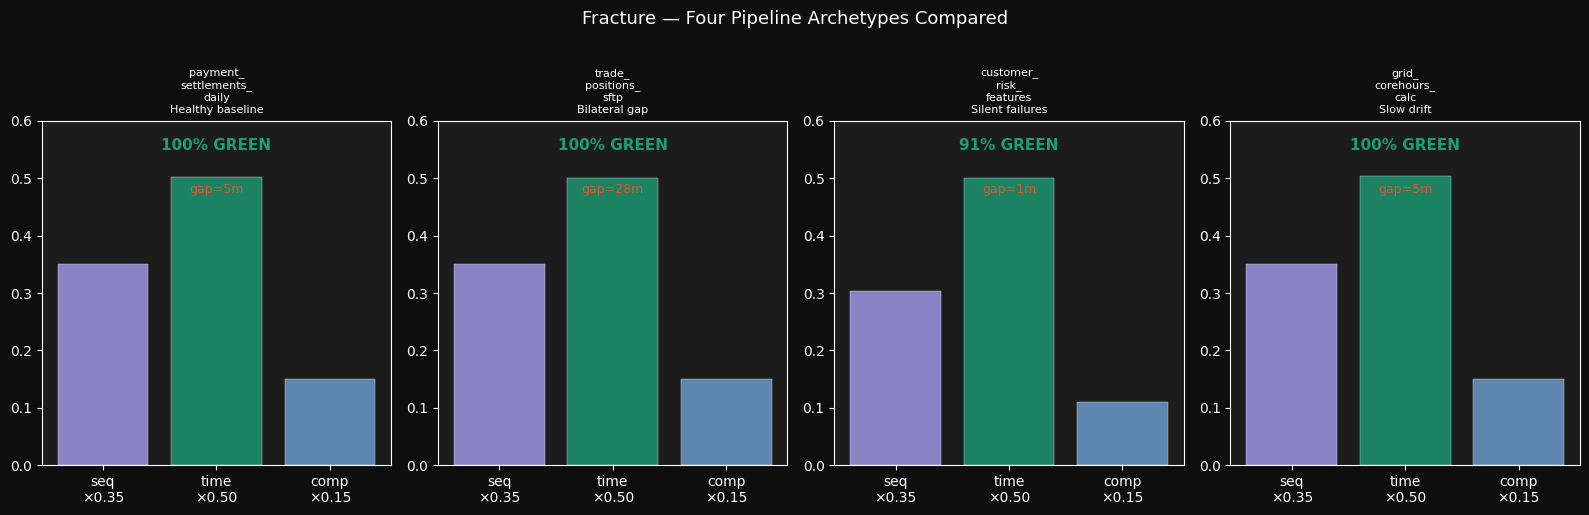


PIPELINE                            SCORE    ZONE       PATTERN        GAP          SUMMARY
-----------------------------------------------------------------------------------------------
payment_settlements_daily           100%    GREEN      STABLE         5 min        Conformant at 100%. GREEN zone. No actio
trade_positions_sftp                100%    GREEN      STABLE         28 min       Pipeline healthy but bilateral gap is 28
customer_risk_features              91%    GREEN      INTERMITTENT   1 min        Fails on specific weekdays — infrastruct
grid_corehours_calc                 100%    GREEN      STABLE         5 min        Conformant at 100%. GREEN zone. No actio


In [18]:
# Side by side comparison
results = [
    ('payment_settlements_daily', result,  'Healthy baseline'),
    ('trade_positions_sftp',      result2, 'Bilateral gap'),
    ('customer_risk_features',    result3, 'Silent failures'),
    ('grid_corehours_calc',       result4, 'Slow drift'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Fracture — Four Pipeline Archetypes Compared', fontsize=13, color='white', y=1.02)

zone_colors = {'GREEN': TEAL, 'AMBER': AMBER, 'RED': RED, 'BREACH': '#8B0000'}

for ax, (pid, r, desc) in zip(axes, results):
    d          = r.diagnostics
    components = [d.sequence_fitness*0.35, d.timing_score*0.50, d.completeness_score*0.15]
    labels     = ['seq\n×0.35', 'time\n×0.50', 'comp\n×0.15']
    colors     = [PURPLE, TEAL, BLUE]
    
    ax.bar(labels, components, color=colors, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axhline(y=r.final_score, color=zone_colors.get(r.timing_zone, AMBER),
               linestyle='--', linewidth=2)
    
    ax.set_ylim(0, 0.6)
    ax.set_title(f'{pid.replace("_", "_\n")}\n{desc}',
                 fontsize=8, color='white')
    ax.text(0.5, 0.95, f'{r.final_score:.0%} {r.timing_zone}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=11, fontweight='bold',
            color=zone_colors.get(r.timing_zone, AMBER))
    
    gap_text = f'gap={r.bilateral_gap_minutes:.0f}m' if r.bilateral_gap_minutes else ''
    ax.text(0.5, 0.82, gap_text, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color=RED)
    
    ax.set_facecolor('#1C1C1C')

fig.patch.set_facecolor('#0E0E0E')
plt.tight_layout()
plt.show()

print()
print(f'{"PIPELINE":<35} {"SCORE":<8} {"ZONE":<10} {"PATTERN":<14} {"GAP":<12} SUMMARY')
print('-' * 95)
for pid, r, _ in results:
    gap = f'{r.bilateral_gap_minutes:.0f} min' if r.bilateral_gap_minutes else '─'
    print(f'{pid:<35} {r.final_score:.0%}    {r.timing_zone:<10} {r.pattern:<14} {gap:<12} {r.human_summary()[:40]}')

---
## The Petri Net — making the contract formal

This is what Fracture actually measures against.
Not a threshold. Not a rule. A formal process model derived from the contract.
Token replay checks whether execution traces conform to this model.

In [19]:
# Show the Petri net structure for payment_settlements_daily
contract = load_contract_for('payment_settlements_daily')
net, im, fm = contract_to_petri_net(contract)
s = net_summary(contract)

print('Petri net derived from payment_settlements_daily contract:')
print(f'  Places      : {s["n_places"]}  (circles — process states)')
print(f'  Transitions : {s["n_transitions"]}  (rectangles — activities)')
print(f'  Arcs        : {s["n_arcs"]}  (connections)')
print(f'  Soundness   : {s["soundness_basis"]}')
print()
print('Places (process states):')
for p in sorted(net.places, key=lambda x: x.name):
    in_mark  = '◉' if p in im else '○'
    end_mark = '◎' if p in fm else ''
    print(f'  {in_mark} {p.name} {end_mark}')
print()
print('Transitions (activities from contract):')
for t in sorted(net.transitions, key=lambda x: x.name):
    label = t.label if t.label else '(silent)'
    print(f'  [{label}]')
print()
print('Process flow:')
print('  p_start → [SCHEDULED] → p1 → [STARTED] → p2')
print('          → [COMPLETED] → p3 → [DATA_AVAILABLE] → p4')
print('          → [t_end silent] → p_end')
print()
print('Token replay fires each transition when the matching activity')
print('appears in the trace. Missing activity = missing token.')
print('Missing tokens reduce sequence_fitness.')

Petri net derived from payment_settlements_daily contract:
  Places      : 6  (circles — process states)
  Transitions : 5  (rectangles — activities)
  Arcs        : 10  (connections)
  Soundness   : trivially guaranteed — strictly linear WF-net: 1-bounded, single path, all transitions reachable, no residual tokens possible

Places (process states):
  ○ payment_settlements_daily_after_completed 
  ○ payment_settlements_daily_after_data_available 
  ○ payment_settlements_daily_after_scheduled 
  ○ payment_settlements_daily_after_started 
  ○ payment_settlements_daily_end ◎
  ◉ payment_settlements_daily_start 

Transitions (activities from contract):
  [COMPLETED]
  [DATA_AVAILABLE]
  [SCHEDULED]
  [STARTED]
  [(silent)]

Process flow:
  p_start → [SCHEDULED] → p1 → [STARTED] → p2
          → [COMPLETED] → p3 → [DATA_AVAILABLE] → p4
          → [t_end silent] → p_end

Token replay fires each transition when the matching activity
appears in the trace. Missing activity = missing token.
Mis

In [ ]:
# Try to visualise if Graphviz is available
try:
    import subprocess
    r = subprocess.run(['dot', '-V'], capture_output=True)
    if r.returncode == 0:
        from pathlib import Path
        Path('../outputs').mkdir(exist_ok=True)
        pm4py.save_vis_petri_net(net, im, fm, '../outputs/petri_net_payment.png')
        print('Petri net saved to outputs/petri_net_payment.png')
        from IPython.display import Image
        display(Image('../outputs/petri_net_payment.png'))
    else:
        print('Graphviz not installed — install it to see the visual Petri net')
        print('  Windows: choco install graphviz')
        print('  Mac:     brew install graphviz')
        print('  Linux:   apt install graphviz')
except Exception as e:
    print(f'Graphviz not available: {e}')
    print('Petri net structure printed above instead.')

In [ ]:
# Performance DFG — shows average timing on each arc
# This is where the bilateral gap becomes visible as an arc
try:
    prod2, cons2 = load_events('trade_positions_sftp')
    contract2    = load_contract_for('trade_positions_sftp')
    
    log_p = dataframe_to_eventlog(prod2, contract2, 'producer')
    log_c = dataframe_to_eventlog(cons2, contract2, 'consumer')
    
    perf_p, sp, ep = pm4py.discover_performance_dfg(log_p)
    perf_c, sc, ec = pm4py.discover_performance_dfg(log_c)
    
    print('Performance DFG — average seconds between activities')
    print()
    print('PRODUCER side:')
    for (a,b), stats in sorted(perf_p.items()):
        print(f'  {a} → {b}: {stats["mean"]/60:.1f} min avg')
    
    print()
    print('CONSUMER side:')
    for (a,b), stats in sorted(perf_c.items()):
        print(f'  {a} → {b}: {stats["mean"]/60:.1f} min avg')
    
    print()
    print('The COMPLETED → DATA_AVAILABLE arc on consumer side is larger.')
    print('That difference is the bilateral gap in the process model.')
    
    # Save PNGs if Graphviz available
    r = subprocess.run(['dot', '-V'], capture_output=True)
    if r.returncode == 0:
        pm4py.save_vis_performance_dfg(perf_p, sp, ep,
                                        '../outputs/dfg_producer.png')
        pm4py.save_vis_performance_dfg(perf_c, sc, ec,
                                        '../outputs/dfg_consumer.png')
        print('Saved: outputs/dfg_producer.png and outputs/dfg_consumer.png')
        print('Open both side by side — the gap is visible on the DATA_AVAILABLE arc')
        
except Exception as e:
    print(f'Performance DFG: {e}')